In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#### Question 1: Pareto Analysis of Automobile Workshop Complaints

An automobile workshop recorded the following customer complaints:

| Complaint Type      | Frequency |
|--------------------|-----------|
| Engine Problem     | 50 |
| Brake Failure      | 20 |
| Battery Issue      | 35 |
| Tire Problem       | 15 |
| Oil Leakage        | 30 |
| Electrical Fault   | 25 |

Tasks

1. Prepare a Pareto analysis.
2. Determine the top 80% problem sources.
3. Suggest priority areas for improvement. 

In [9]:
import pandas as pd

df = pd.DataFrame({
    "Complaint Type": [
        "Engine Problem",
        "Brake Failure",
        "Battery Issue",
        "Tire Problem",
        "Oil Leakage",
        "Electrical Fault"
    ],
    "Frequency": [50, 20, 35, 15, 30, 25]
})

df = df.sort_values('Frequency',ascending=False)

In [10]:
total_complaints = df['Frequency'].sum()
print(f'Total Complaints = ', total_complaints)
df['Percentage'] = (df['Frequency']/total_complaints )* 100
df['Cumulative Frequency'] = df['Frequency'].cumsum()
df['Cumulative Percentage'] = (df['Cumulative Frequency'] /total_complaints) * 100
df

Total Complaints =  175


,Complaint Type,Frequency,Percentage,Cumulative Frequency,Cumulative Percentage
0,Engine Problem,50,28.571429,50,28.571429
2,Battery Issue,35,20.000000,85,48.571429
4,Oil Leakage,30,17.142857,115,65.714286
5,Electrical Fault,25,14.285714,140,80.000000
1,Brake Failure,20,11.428571,160,91.428571
3,Tire Problem,15,8.571429,175,100.000000


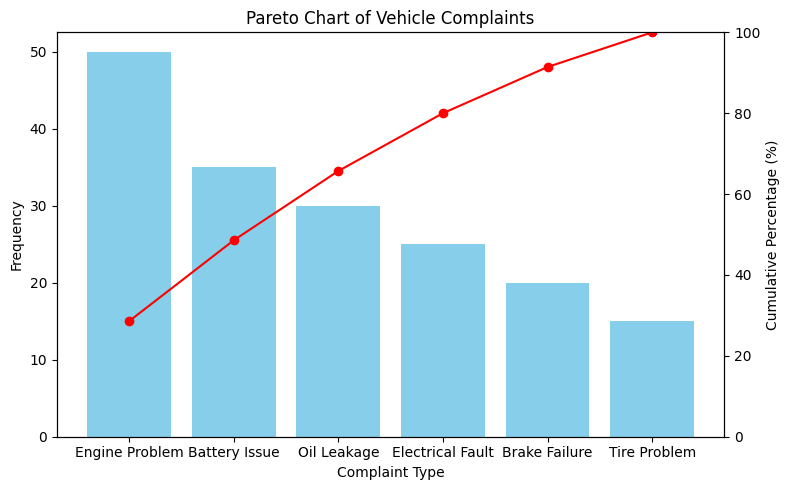

In [11]:

# Plot
fig, ax1 = plt.subplots(figsize=(8, 5))

# Bar chart
ax1.bar(df["Complaint Type"], df["Frequency"], color="skyblue")
ax1.set_ylabel("Frequency")
ax1.set_xlabel("Complaint Type")

# Cumulative percentage line
ax2 = ax1.twinx()
ax2.plot(
    df["Complaint Type"],
    df["Cumulative Percentage"],
    color="red",
    marker="o"
)
ax2.set_ylabel("Cumulative Percentage (%)")
ax2.set_ylim(0, 100)

plt.title("Pareto Chart of Vehicle Complaints")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Top problems (vital few) 
The 80% reaches at ``Electrical Fault`` so the top problems are: ``Engine Problem`` ``Battery Issue``, ``Oil leakage`` and ``Electric Fault``

##### Suggested priority areas for improvement 
Since *Engine Problems* contribute the largest number of complaints, they should receive the highest priority. Attention should also be given to *Battery Issues*, *Oil Leakage*, and *Electrical Faults* because together they account for approximately 80% of customer complaints.

____________________

#### Question 2: Scatter Diagram and Correlation

| Training Hours | Productivity Score |
|---------------:|-------------------:|
| 2 | 40 |
| 3 | 45 |
| 4 | 50 |
| 5 | 55 |
| 6 | 60 |
| 7 | 65 |
| 8 | 70 |
| 9 | 75 |

Tasks

1. Draw a scatter diagram.
2. Determine the type of relationship.
3. Calculate the correlation coefficient.
4. Interpret the result.

In [12]:
data = {
    "Training Hours": [2, 3, 4, 5, 6, 7, 8, 9],
    "Productivity Score": [40, 45, 50, 55, 60, 65, 70, 75]
}
df = pd.DataFrame(data)

In [13]:
def plot_scatter_with_lor(x,y, x_label, y_label):
    fig, ax = plt.subplots()
    ax.scatter(x,y )
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    a, b = np.polyfit(x, y, 1)
    ax.plot(x,b+a*x, color="k", lw=1)

    plt.show()

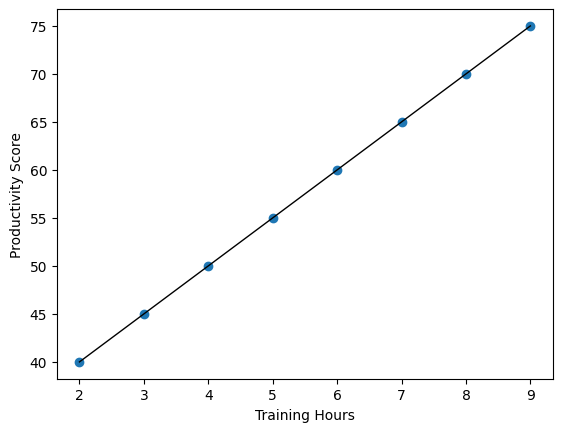

In [14]:
x=df['Training Hours']
y=df['Productivity Score']
x_label = 'Training Hours'
y_label = 'Productivity Score'
plot_scatter_with_lor(x, y, x_label, y_label)

In [15]:
def compute_cor_coefficient(df_table_x_y):
    df_table_x_y['x_sq'] = np.square(df_table_x_y['x'])
    df_table_x_y['y_sq'] = np.square(df_table_x_y['y'])
    df_table_x_y['xy']= df_table_x_y['x'] * df_table_x_y['y']

    n=len(df_table_x_y)
    sum_x = df_table_x_y['x'].sum()
    sum_y = df_table_x_y['y'].sum()
    sum_x_sq = df_table_x_y['x_sq'].sum()
    sum_y_sq = df_table_x_y['y_sq'].sum()
    sum_xy = df_table_x_y['xy'].sum()

    r = (n * sum_xy - sum_x * sum_y) / np.sqrt( (n * sum_x_sq - np.square(sum_x)) * (n * sum_y_sq - np.square(sum_y)))

    return r

In [16]:
table = df[['Training Hours', 'Productivity Score']].rename(
    columns={
        'Training Hours': 'x',
        'Productivity Score': 'y'
    }
)
r = compute_cor_coefficient(table)
print('Correlation Coefficient = ',r)

Correlation Coefficient =  1.0


##### Interpretation
The scatter diagram shows that  ``Productivity Score``  increases as ``Training Hours`` increases. This suggests that there is **positive linear relationship** between the two variables.

Furthurmore, the **correlation coefficient (r=1)** indicates a **perfect positive linear correlation** between ``Productivity Score`` and  ``Training Hours``.

____________________

#### Question 3: Scatter Diagram and Correlation Analysis

| Machine Age (Years) | Maintenance Cost ($) |
|--------------------:|---------------------:|
| 1 | 200 |
| 2 | 250 |
| 3 | 300 |
| 4 | 380 |
| 5 | 450 |
| 6 | 520 |
| 7 | 610 |
| 8 | 720 |


1. Plot a scatter diagram.
2. Compute the correlation coefficient.
3. Determine whether the relationship is positive or negative.
4. Estimate the maintenance cost trend.

In [17]:
df = pd.DataFrame({
    'Machine Age (Years)': [1, 2, 3, 4, 5, 6, 7, 8],
    'Maintenance Cost ($)': [200, 250, 300, 380, 450, 520, 610, 720]
})

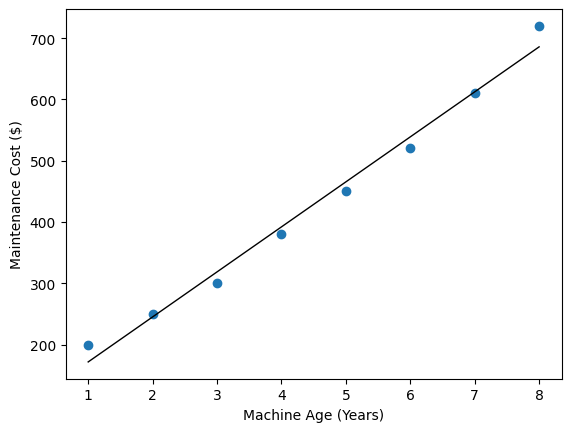

In [18]:
x_var = 'Machine Age (Years)'
y_var = 'Maintenance Cost ($)'
plot_scatter_with_lor(df[x_var],df[y_var],x_var, y_var)

In [19]:
table = df.rename(columns={
    x_var : 'x',
    y_var: 'y'
})
r = compute_cor_coefficient(table)
print('Correlation coefficient = ', r)

Correlation coefficient =  0.9932574765095138


##### Interpretation
The scatter diagram shows that  ``Maintainance Cost``  increases as ``Machine Age`` increases. This suggests that there is **positive linear relationship** between the two variables.

Furthurmore, the **correlation coefficient (r=0.99)** indicates a **strong positive linear correlation** between ``Maintainance Cost`` and  ``Machine Age``.
Therefore, as the machine gets old, its maintainence cost increases. 

_________

#### Question 4: X̄-Chart (Mean Control Chart)

The following are the sample means obtained from 10 samples, each of size 5.

| Sample | Mean |
|--------|-----:|
| 1 | 25 |
| 2 | 27 |
| 3 | 26 |
| 4 | 28 |
| 5 | 29 |
| 6 | 30 |
| 7 | 26 |
| 8 | 27 |
| 9 | 25 |
| 10 | 28 |

- Overall Average = 27.1
- Average Range = 4
- A_2 = 0.577

Tasks

1. Compute UCL and LCL.
2. Draw the X̄-chart.
3. Determine whether the process is in control.

In [20]:
mean_x = 27.1
mean_r = 4
A2 = 0.577

CL = mean_x
UCL = mean_x + A2*mean_r
LCL = mean_x - A2*mean_r

print('Upper control unit (UCL) = ', UCL)
print('Lower control unit (LCL) = ', LCL)

Upper control unit (UCL) =  29.408
Lower control unit (LCL) =  24.792


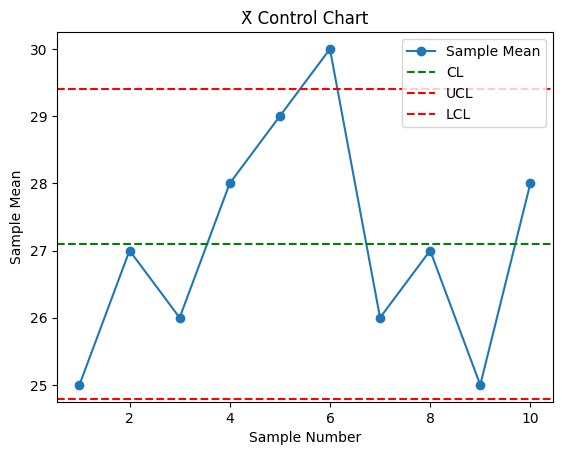

In [21]:
sample_no = [1,2,3,4,5,6,7,8,9,10]
means = [25,27,26,28,29,30,26,27,25,28]

plt.plot(sample_no, means, marker='o', label='Sample Mean')

plt.axhline(CL, color='green', linestyle='--', label='CL')
plt.axhline(UCL, color='red', linestyle='--', label='UCL')
plt.axhline(LCL, color='red', linestyle='--', label='LCL')

plt.xlabel('Sample Number')
plt.ylabel('Sample Mean')
plt.title('X̄ Control Chart')
plt.legend(loc='upper right')
plt.show()

##### Interpretation
The X̄-Chart has central line of 27.1, upper control limit of approximately 29.41, and a lower control line of approximately 24.79. \
Most of the samples lie within the control limits. However sample 6 has mean value of 30 and crosses the upper control limit. This kind of sudden spike can be interpreted as having a special cause variation that should be investigated. \
Since one point falls outside the contol limits, the process is considered statistically out of control.

____

#### Question 5: p-Chart (Proportion Defective Chart)

A quality inspector checks 12 samples of size 100 each.

| Sample | Number of Defectives |
|--------|---------------------:|
| 1 | 4 |
| 2 | 5 |
| 3 | 3 |
| 4 | 6 |
| 5 | 5 |
| 6 | 7 |
| 7 | 4 |
| 8 | 5 |
| 9 | 6 |
| 10 | 5 |
| 11 | 4 |
| 12 | 3 |

Tasks

1. Compute the average defective proportion.
2. Determine UCL and LCL.
3. Draw the p-chart.
4. Comment on process stability.

In [22]:
sample_no = [1,2,3,4,5,6,7,8,9,10,11,12]
defectives = [4,5,3,6,5,7,4,5,6,5,4,3]
pi = [d/100 for d in defectives]

total_samples = 12
sample_size = 100

# Center line (CL)
CL = np.sum(defectives) / (total_samples * sample_size)

# Upper control limit(UCL)
UCL = CL + 3 * np.sqrt((CL * (1-CL))/sample_size)

# Lower Control Limit (LCL)
LCL = CL - 3 * np.sqrt((CL * (1-CL))/sample_size)
LCL = 0 if LCL < 0 else LCL

print('Central line = ', CL)
print('Upper Control Limit(UCL) = ', UCL)
print('Lower Control Limit(LCL) = ', LCL)

Central line =  0.0475
Upper Control Limit(UCL) =  0.11131173481421736
Lower Control Limit(LCL) =  0


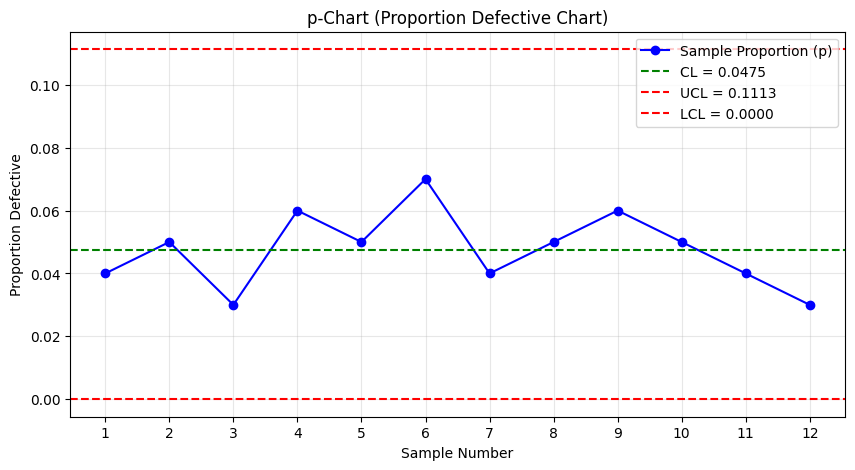

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(sample_no, pi, marker='o', linestyle='-', color='blue', label='Sample Proportion (p)')

plt.axhline(CL, color='green', linestyle='--', label=f'CL = {CL:.4f}')

plt.axhline(UCL, color='red', linestyle='--', label=f'UCL = {UCL:.4f}')

plt.axhline(LCL, color='red', linestyle='--', label=f'LCL = {LCL:.4f}')

plt.title('p-Chart (Proportion Defective Chart)')
plt.xlabel('Sample Number')
plt.ylabel('Proportion Defective')
plt.xticks(sample_no)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

##### Interpretation

No point falls above Upper Control Limit (0.11) or lies below Lower Control Limit (0). \
The process is statistically in control.

___

##### Question 6: c-Chart (Number of Defects Chart)

The number of defects observed in 15 cloth rolls are:

4, 5, 6, 4, 3, 5, 7, 6, 5, 4, 5, 6, 4, 5, 3

Tasks

1. Compute the average number of defects.
2. Calculate control limits.
3. Draw the c-chart.
4. Identify any out-of-control condition.

In [24]:
roll_no = np.array(range(1,16))
defects = np.array([4, 5, 6, 4, 3, 5, 7, 6, 5, 4, 5, 6, 4, 5, 3])
defects_avg = np.sum(defects) / len(defects)

CL = defects_avg

UCL = CL + 3 * np.sqrt(CL)

LCL = CL - 3 * np.sqrt(CL)
LCL = 0 if LCL < 0 else LCL

print('Average no of defects = ', defects_avg)
print('Central limit (CL)= ', CL)
print('Upper Central limit (UCL)= ', UCL)
print('Lower Central limit (LCL)= ', LCL)

Average no of defects =  4.8
Central limit (CL)=  4.8
Upper Central limit (UCL)=  11.372670690061993
Lower Central limit (LCL)=  0


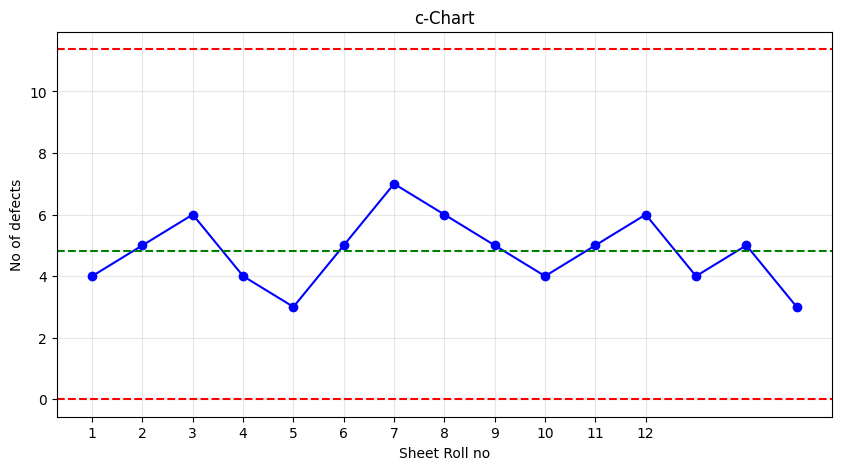

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(roll_no, defects, marker='o', linestyle='-', color='blue', label='No of defects')

plt.axhline(CL, color='green', linestyle='--', label=f'CL = {CL:.4f}')

plt.axhline(UCL, color='red', linestyle='--', label=f'UCL = {UCL:.4f}')

plt.axhline(LCL, color='red', linestyle='--', label=f'LCL = {LCL:.4f}')

plt.title('c-Chart')
plt.xlabel('Sheet Roll no')
plt.ylabel('No of defects')
plt.xticks(sample_no)
plt.grid(True, alpha=0.3)
plt.show()

##### Interpretation

The c-chart has an average number of defects of approximately 4.8 defects per cloth roll. The upper control limit (UCL) is approximately 11.37, while the lower control limit (LCL) is 0.

All observed defect counts lie within the control limits. No points exceed the UCL or fall below the LCL, indicating that the variation in the number of defects is due to common causes rather than special causes.

Therefore, the process is statistically in control.

___

#### Question 7: Quality Improvement Analysis

A food processing company collected the following defect data over one month.

| Defect Type | Frequency |
|-------------|----------:|
| Underweight Package | 55 |
| Leakage | 35 |
| Wrong Label | 20 |
| Seal Damage | 45 |
| Contamination | 15 |
| Expired Product | 10 |

Tasks

1. Prepare a check sheet.
2. Draw a Pareto chart.
3. Identify major defects.
4. Suggest possible root causes using an Ishikawa (Fishbone) diagram.
5. Recommend quality improvement strategies.

In [26]:
import pandas as pd
data = {
    "Defect Type": [
        "Underweight Package",
        "Leakage",
        "Wrong Label",
        "Seal Damage",
        "Contamination",
        "Expired Product"
    ],
    "Frequency": [55, 35, 20, 45, 15, 10]
}
df = pd.DataFrame(data)

print(df)

           Defect Type  Frequency
0  Underweight Package         55
1              Leakage         35
2          Wrong Label         20
3          Seal Damage         45
4        Contamination         15
5      Expired Product         10


In [27]:
df = df.sort_values('Frequency', ascending=False)
total_frequency = df['Frequency'].sum()
df['Percentage'] = (df['Frequency']/ total_frequency)*100
df['Cumulative Frequency'] = df['Frequency'].cumsum()
df['Cumulative Percentage'] = (df['Cumulative Frequency'] / total_frequency) * 100
df

,Defect Type,Frequency,Percentage,Cumulative Frequency,Cumulative Percentage
0,Underweight Package,55,30.555556,55,30.555556
3,Seal Damage,45,25.000000,100,55.555556
1,Leakage,35,19.444444,135,75.000000
2,Wrong Label,20,11.111111,155,86.111111
4,Contamination,15,8.333333,170,94.444444
5,Expired Product,10,5.555556,180,100.000000


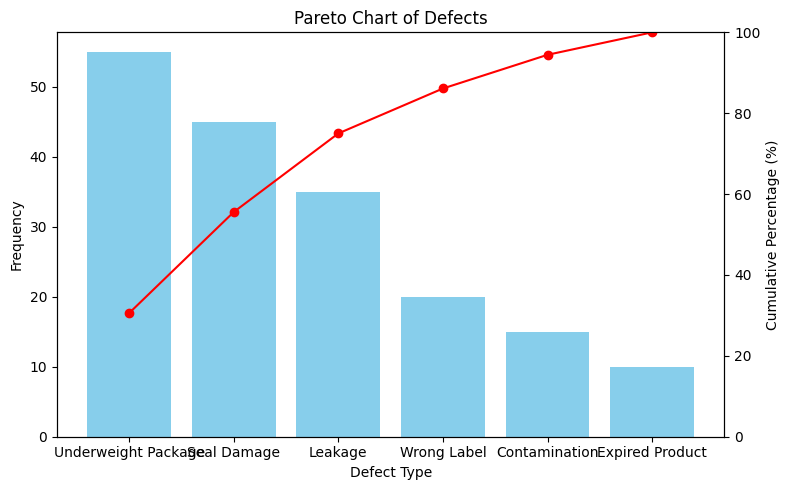

In [32]:
# Plot
fig, ax1 = plt.subplots(figsize=(8, 5))

# Bar chart
ax1.bar(df["Defect Type"], df["Frequency"], color="skyblue")
ax1.set_ylabel("Frequency")
ax1.set_xlabel("Defect Type")

# Cumulative percentage line
ax2 = ax1.twinx()
ax2.plot(
    df["Defect Type"],
    df["Cumulative Percentage"],
    color="red",
    marker="o"
)

ax2.set_ylabel("Cumulative Percentage (%)")
ax2.set_ylim(0, 100)

plt.title("Pareto Chart of Defects")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Interpretation Pareto Chart
From the Pareto Chart we can see that the the 80% coumultive frequency cut off occurs at third highest defect type. Wrong Label increases the cumulative contribution to 866%, exceeding the 80%. So major defects identified from Pareto analysis are: 
1. Unerwater Package
2. Seal damage
3. Leakage

These defects account for approximately 80% of all observed defects and should receive the highest priority for corrective action.

#### Ishikawa (Fishbone) Analysis for (Underweight Package, Seal Damage and Leakage)

| Category (6M) | Possible Root Causes |
|--------------|---------------------|
| Man (People) | Inadequate operator training, failure to follow SOPs, incorrect machine settings, careless handling of packages, insufficient supervision |
| Machine | Filling machine malfunction, worn sealing equipment, improper machine calibration, equipment breakdowns, poor preventive maintenance |
| Method | Incorrect filling procedures, improper sealing procedures, lack of standardized work instructions, inadequate quality inspection process, poor process control |
| Material | Low-quality packaging material, weak sealing film, defective containers or pouches, damaged packaging supplies, supplier quality issues |
| Measurement | Uncalibrated weighing scales, faulty measuring instruments, incorrect inspection criteria, inaccurate quality checks, data recording errors |
| Environment | High humidity, excessive temperature variations, dust and contamination, poor storage conditions, inadequate workplace cleanliness |

![Fishbone Diagram](images/fishbone.png)

##### Recommended Quality Improvement Strategies

| Category | Recommended Improvement Strategy |
|-----------|---------------------------------|
| Man (People) | Provide regular operator training, reinforce adherence to Standard Operating Procedures (SOPs), improve supervision, and establish accountability for quality performance. |
| Machine | Implement preventive maintenance programs, regularly calibrate filling and sealing equipment, replace worn components, and monitor machine performance. |
| Method | Standardize operating procedures, document work instructions clearly, conduct process audits, and improve quality control checkpoints throughout production. |
| Material | Strengthen supplier quality management, inspect incoming packaging materials, establish material acceptance criteria, and work with suppliers to reduce material defects. |
| Measurement | Calibrate weighing scales and measuring devices regularly, improve inspection procedures, automate data collection where possible, and verify measurement accuracy. |
| Environment | Maintain proper temperature and humidity levels, improve workplace cleanliness, implement contamination control measures, and ensure proper storage conditions for materials and products. |

##### Overall Recommendation

Based on the Pareto analysis, improvement efforts should primarily focus on reducing Underweight Package, Seal Damage, and Leakage defects, as these account for the majority of quality issues. Implementing the above strategies will help improve process consistency, reduce defect rates, and enhance overall product quality.

___

#### Question 8: Histogram and Statistical Process Control

A company monitors daily production output for 20 days.

120, 122, 119, 121, 124, 125, 123, 122, 121, 120, 119, 118, 122, 123, 124, 126, 127, 125, 124, 123

Tasks

1. Prepare a histogram.
2. Compute the mean and standard deviation.
3. Construct control limits.
4. Determine whether production is statistically controlled.

In [38]:
output = [
    120, 122, 119, 121, 124,
    125, 123, 122, 121, 120,
    119, 118, 122, 123, 124,
    126, 127, 125, 124, 123
]

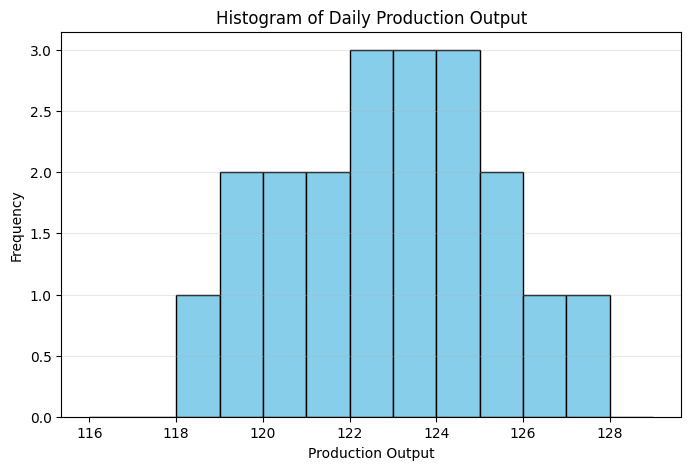

In [41]:
plt.figure(figsize=(8, 5))

plt.hist(
    output,
    bins=range(116, 130),  # one bin per production value
    edgecolor='black',
    color='skyblue'
)

plt.title('Histogram of Daily Production Output')
plt.xlabel('Production Output')
plt.ylabel('Frequency')

plt.grid(axis='y', alpha=0.3)
plt.show()

In [48]:
n = len(output)
mean_x = np.sum(output)/len(output)
squared_deviations = [(x - mean_x)**2 for x in output]
std = np.sqrt(np.sum(squared_deviations)/(n-1))

print('Mean = ', mean_x)
print('Standard deviation = ', std)

Mean =  122.4
Standard deviation =  2.458069417888334


In [49]:
#Control Limits
CL = mean_x
UCL = mean_x + 3 * std
LCL = mean_x - 3 * std

print('Central line = ', CL)
print('Upper Control Limit(UCL) = ', UCL)
print('Lower Control Limit(LCL) = ', LCL)


Central line =  122.4
Upper Control Limit(UCL) =  129.774208253665
Lower Control Limit(LCL) =  115.025791746335


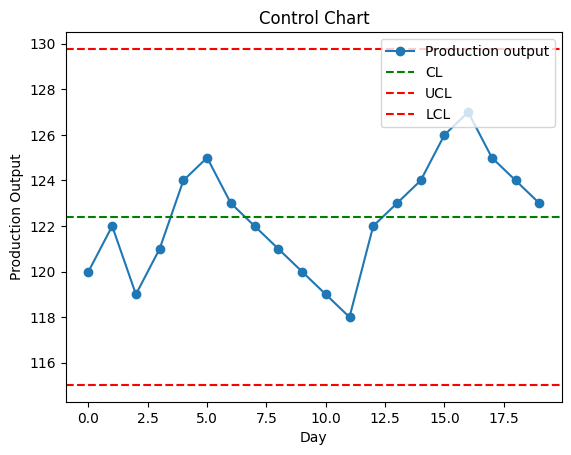

In [52]:

plt.plot(output, marker='o', label='Production output')

plt.axhline(CL, color='green', linestyle='--', label='CL')
plt.axhline(UCL, color='red', linestyle='--', label='UCL')
plt.axhline(LCL, color='red', linestyle='--', label='LCL')


plt.title("Control Chart")
plt.xlabel("Day")
plt.ylabel("Production Output")
plt.legend(loc='upper right')
plt.show()

##### Interpretation
Although though all the points lies between upper control limit and lower control limit, the data shows a clear non random pattern. The chart shows the pattern where values rises first 5 days, then falls next 5-6 days and then rise again. This pattern indicates the presence of a trend, suggesting that the process may be influenced by special causes. Therefore, the process is statistically out of control.